In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir("..")

from utils import clean_utils

*League of Legends* es un juego complicado en el que puedes elegir muchos campeones. Cada campeón, se juega de manera distinta ya que tiene sus propias habilidades y patrones de juego.

Como decía una de nuestras hipótesis, vamos a analizar la relación entre el nivel de maestría de un campeón y el rendimiento.

En primer lugar, debemos conseguir las variables pertinentes.

In [ ]:
individual_stats = pd.read_csv("datasets/individual_stats.csv", sep=",")
individual_stats["CurrentMasteryPoints"].value_counts().sort_index()

CurrentMasteryPoints
0      241013
1         394
2         468
3        1218
4         780
        ...  
901      1995
902      1357
904      1647
910      1061
950      1035
Name: count, Length: 173, dtype: int64

Por alguna razón hay muchos 0. Esto no es normal, ya que simplemente con haber jugado 1 partida con un campeón deberías tener un nivel de maestría de 1. Vamos a eliminarlos del dataset ya que considero que se pueden deber a un error de recopilación.
- Como después vamos a analizar por rango, también eliminamos los registros de *unranked*.

In [5]:
mastery_df = individual_stats[(individual_stats["RankFk"] != 0) & (individual_stats["CurrentMasteryPoints"] > 0)]
mastery_df["CurrentMasteryPoints"].describe()

count    148985.000000
mean        216.407672
std         260.420404
min           1.000000
25%          51.000000
50%         110.000000
75%         238.000000
max         950.000000
Name: CurrentMasteryPoints, dtype: float64

El nivel de maestría va desde 1 hasta el infinito (si juegas lo suficiente). Por ello, vamos a crear segmentos para categorizar cada nivel de maestría. Usaremos los cuartiles calculados con el método *qcut()* de pandas.
- Baja (Q1)
- Media-Baja (Q2)
- Media-Alta (Q3)
- Alta (Q4)

In [7]:
mastery_df["MasterySegments"] = pd.qcut(mastery_df["CurrentMasteryPoints"], q=4, 
                                        labels=["Q1 (Baja)", "Q2 (Media-Baja)", "Q3 (Media-Alta)", "Q4 (Alta)"])

print(mastery_df.groupby("MasterySegments")["CurrentMasteryPoints"].agg(["min", "max", "mean"]))

                 min  max        mean
MasterySegments                      
Q1 (Baja)          1   51   25.433857
Q2 (Media-Baja)   53  110   79.692713
Q3 (Media-Alta)  111  238  163.690733
Q4 (Alta)        240  950  606.058777


Cogemos las métricas que muestran el rendimiento en una partida.
- Calculamos la media y la desviación estándar.

In [9]:
metrics = ["kills", "deaths", "assists", "DmgDealt", "Win"]
perf = mastery_df.groupby("MasterySegments")[metrics].agg(["mean", "std"]).round(3)
perf


kills        deaths        assists          DmgDealt  \
                  mean    std   mean    std    mean    std       mean   
MasterySegments                                                         
Q1 (Baja)        5.748  4.695  5.825  3.335   8.150  6.058  21449.120   
Q2 (Media-Baja)  6.179  4.607  5.718  3.327   7.785  5.657  21792.676   
Q3 (Media-Alta)  6.392  4.982  5.858  3.307   7.799  5.786  21712.184   
Q4 (Alta)        5.651  4.844  5.814  3.313   8.448  6.613  20404.899   

                              Win       
                       std   mean  std  
MasterySegments                         
Q1 (Baja)        13437.959  0.509  0.5  
Q2 (Media-Baja)  12748.452  0.504  0.5  
Q3 (Media-Alta)  13313.468  0.505  0.5  
Q4 (Alta)        13500.652  0.495  0.5

Ahora que tenemos los segmentos, vamos a visualizar si los jugadores de maestrías altas presentan rendimientos más consistentes (menos desviación estándar).

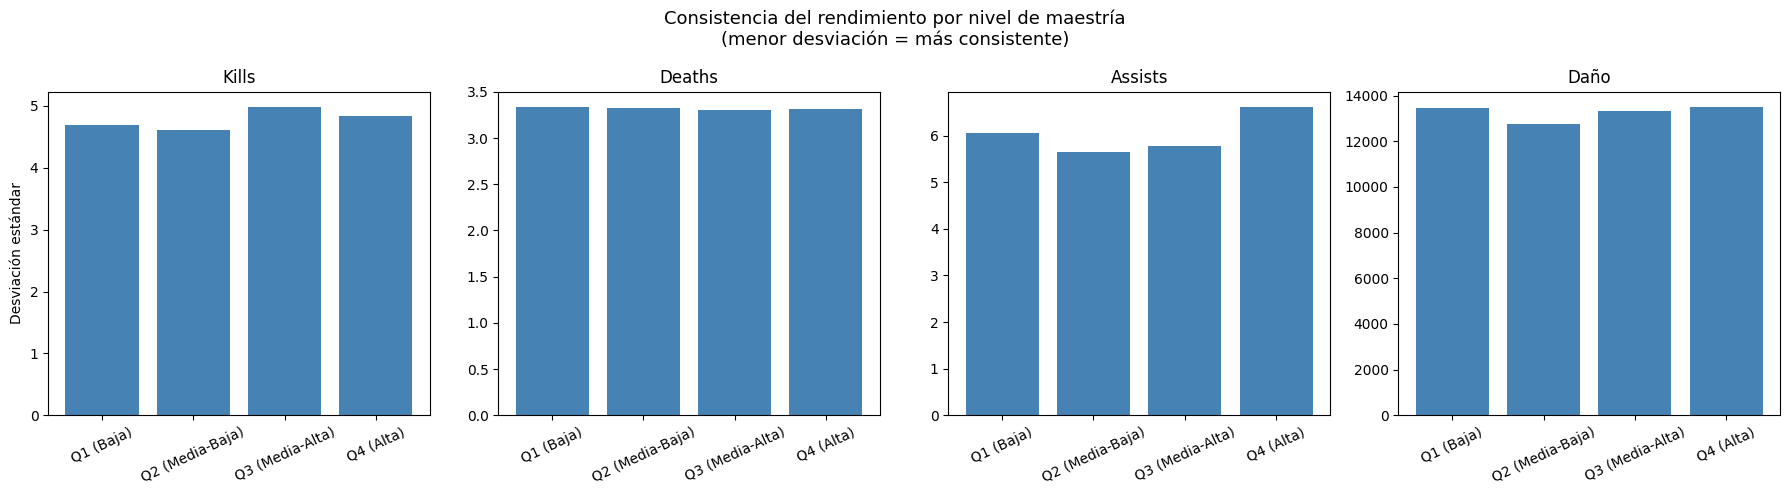

In [ ]:
std_df = mastery_df.groupby("MasterySegments")[["kills", "deaths", "assists", "DmgDealt"]].std().reset_index()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metric_labels = {
    "kills": "Kills",
    "deaths": "Deaths",
    "assists": "Assists",
    "DmgDealt": "Daño"
}

for ax, (col, label) in zip(axes, metric_labels.items()):
    ax.bar(std_df["MasterySegments"], std_df[col], color="steelblue")
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("Desviación estándar" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Consistencia del rendimiento por nivel de maestría\n(menor desviación = más consistente)", fontsize=13)
plt.tight_layout()

Podemos observar que el rendimiento no cambia realmente entre niveles de maestrías. Con los datos actuales, no puedo ni confirmar ni refutar la hipótesis ya que:
- El nivel de maestría que muestra la columna no parece ajustarse a como Riot expone de cara público sus niveles de maestría.
- Los rangos los hemos creado nosotros de manera arbitraria, es decir, los hemos dividido en 4.
    - Realmente, a partir de maestría 7 (en la escala real que Riot pone de cara al público), ya se considera que alguien ha jugado mucho un campeón y tiene bastante maestría con él.

Por esto y por el error previo de que muchos valores del nivel de meastría eran 0, creo que no se puede realizar un análisis robusto con el valor de esta columna.
